---

numbering: false
---

# 4.4. Lines, Planes, Hyperplanes, and the Cross Product

Think of this section as a brief detour from the main storyline of the course. Here, I'll cover how to describe lines, planes, and hyperplanes in $\mathbb{R}^n$, and how they relate to our understanding of spans and subspaces from earlier in this chapter.

## Lines

### Intuition in $\mathbb{R}^2$ and $\mathbb{R}^3$

We're very familiar with lines in $\mathbb{R}^2$. The line $y = 2x + 3$, in $\mathbb{R}^2$, is the set of all $(x, y)$ coordinates that satisfy the equation $y = 2x + 3$. 

The line $y = 2x + 3$ is in **slope-intercept form**, which more generally looks like $y = w_0 + w_1 x$. Sometimes, we may write lines in **standard form**, like $2x - y + 3 = 0$, or more generally, $ax + by + c = 0$.

Let's kick things up a notch and consider lines in $\mathbb{R}^3$. **What is the equation of the** <span style="color: #004d40; font-weight: bold;">line below</span>?

In [22]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (2, -1, 3)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 100)
line_x = t * v[0]
line_y = t * v[1]
line_z = t * v[2]

fig = plot_vectors([((0, 0, 0), "#3d81f6", r"")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v to the 3D plot
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=5),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Draw small points at (0, 0, 0) and the tip of v
fig.add_trace(
    go.Scatter3d(
        x=[0, v[0]],
        y=[0, v[1]],
        z=[0, v[2]],
        mode="markers",
        marker=dict(size=4, color=["#222", "#222"]),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Add annotations next to the two points: (0,0,0) and (2,-1,3)
fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="text",
        text=["(0, 0, 0)"],
        textposition="top right",
        showlegend=False,
        hoverinfo="skip"
    )
)
fig.add_trace(
    go.Scatter3d(
        x=[v[0]],
        y=[v[1]],
        z=[v[2]],
        mode="text",
        text=[f"({v[0]}, {v[1]}, {v[2]})"],
        textposition="top center",
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    scene=dict(
        xaxis=dict(range=[-4, 4]),
        yaxis=dict(range=[-4, 4]),
        zaxis=dict(range=[-6, 6])
    ),
)

fig.show()

As we saw in [Chapter 4.1](01-span.ipynb), the line shown above is the span of the vector $\color{#3d81f6}\vec v = \begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}$. It passes through the origin, $(0, 0, 0)$, and passes through the point $(2, -1, 3)$.

Ideally, we'd be able to express the line as a function

$$z = f(x, y)$$

as we did in the $\mathbb{R}^2$ case, where $y = f(x) = mx + b$.

Unfortunately, there is no way to express the lines in $\mathbb{R}^3$, or $\mathbb{R}^4$, or $\mathbb{R}^n$ for $n > 2$ as a simple function. Why not? If there were some formula for $z$ (the height of the line) in terms of $x$ and $y$, that would imply that we should be able to plug in **any** $x$ and **any** $y$ to get an output $z$. But, the line above only works for very specific combinations of $x$ and $y$. For instance, there's no point on the line above that has $x = 1$ and $y = 1$. Rather, when $x = 1$, $y$ is forced to be $-\frac{1}{2}$, and $z$ is forced to be $\frac{3}{2}$.

The key idea that I stressed in [Chapter 4.1](01-span.ipynb) is that **lines are 1-dimensional objects**, meaning that the location of any point on the line can be described using a single free variable.

So, the equation of the line above is

$$L = t\begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix}, t \in \mathbb{R}$$

$t$ here is a free variable – sometimes called a parameter (though this term is confusing in the context of our course) – meaning we can set it to whatever we'd like. The line is the set of all points that can be reached by plugging in different values of $t$.

Since the line is really a set of points, I should have written it as

$$L = \{t\begin{bmatrix} 2 \\ -1 \\ 3 \end{bmatrix} \mid t \in \mathbb{R}\}$$

but I'll use the former notation for brevity. 

Equivalently, you can think of the line as three separate functions of $t$. Pick a $t$. Then, $L$ is

$$\begin{align*} x = 2t \\ y = -t \\ z = 3t \end{align*}$$

Drag the value of $t$ below to see how $t$ allows us to move along the line.

In [23]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v = (2, -1, 3)

# Create the line spanned by v (all scalar multiples)
t = np.linspace(-2, 2, 25)
line_x = t * v[0]
line_y = t * v[1]
line_z = t * v[2]

fig = plot_vectors([((0, 0, 0), "#3d81f6", r"")], show_axis_labels=True, vdeltax=0.1)

# Add the line spanned by v to the 3D plot
fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=5),
        showlegend=False,
        hoverinfo="skip"
    )
)

# Add a marker that moves along the line as t changes, controlled by a slider
t_slider = np.linspace(-2, 2, 25)
marker_x = t_slider * v[0]
marker_y = t_slider * v[1]
marker_z = t_slider * v[2]

# Create frames for the moving marker
frames = [
    go.Frame(
        data=[
            go.Scatter3d(
                x=[marker_x[i]],
                y=[marker_y[i]],
                z=[marker_z[i]],
                mode="markers",
                marker=dict(size=8, color="black"),
                showlegend=False,
                hoverinfo="skip"
            )
        ],
        name=str(round(t_slider[i], 2))
    )
    for i in range(len(t_slider))
]

# Find the index where t=0 to set as the default frame
default_t_index = np.argmin(np.abs(t_slider - 0))

# Add slider to control t, set default value to t=0
sliders = [
    {
        "steps": [
            {
                "method": "animate",
                "args": [
                    [str(round(t_slider[i], 2))],
                    {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}
                ],
                "label": f"t={round(t_slider[i],2)}"
            }
            for i in range(len(t_slider))
        ],
        "currentvalue": {"prefix": ""},
        "pad": {"t": 50},
        "active": default_t_index
    }
]

fig.frames = frames
fig.update_layout(
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    sliders=sliders,
    scene=dict(
        xaxis=dict(range=[-5, 5]),
        yaxis=dict(range=[-5, 5]),
        zaxis=dict(range=[-8, 8])
    ),
    # Increase bottom margin to prevent axis ticks from being cut off
    margin=dict(l=0, r=0, t=0, b=130),
    width=650,
    height=600
)

# Show the marker at t=0 by default
fig.add_trace(
    go.Scatter3d(
        x=[0],
        y=[0],
        z=[0],
        mode="markers+text",
        marker=dict(size=8, color="#aaa"),
        showlegend=False,
        hoverinfo="skip",
        text=["at t = 0, line passes through (0, 0, 0)"],
        textposition="top right",
        textfont=dict(color="#333", size=12)
    )
)

fig.show()

The line $L$ above passes through the origin, since if we set $t = 0$, we get the point $(0, 0, 0)$. This matches what we'd expect out of the span of a single vector, since $0 {\color{#3d81f6}\vec v} = \vec 0$.

But how do we express a line that passes through some other fixed point that **isn't** the origin? Such a line might not be the span of a single vector, since the span of a single vector is always a line that passes through the origin. But, it's good to know how to think about lines in this more general form.

### Lines in Parametric Form

:::{note} Definition: Line

A **line** in $\mathbb{R}^n$ that passes through the point $\vec p_0$ and is parallel to the vector $\vec v$ can be described as:

$$L = \vec p_0 + t\vec v, t \in \mathbb{R}$$

This is sometimes called the **parametric form** of the line, since $t$ can be thought of as a parameter.
:::

An **affine subspace** is a translated subspace: a set of the form $\{\vec p_0 + \vec s \mid \vec s \in S\}$, where $S$ is a subspace. When $S$ is one-dimensional, this is an **affine line**; when $S$ is two-dimensional, it is an **affine plane**. Unlike a linear subspace, an affine subspace need not contain the origin.

The definition above is not specific to 2-dimensional or 3-dimensional space – it works in any $\mathbb{R}^n$. (Technically, I'm mixing the meaning of a point and a vector here, but as long as we remember that points describe positions and vectors describe directions, we should be fine.) Here's a line in $\mathbb{R}^{100}$:

$$L = \begin{bmatrix} 1 \\ 2 \\ 3 \\ 4 \\ \vdots \\ 100 \end{bmatrix} + t \begin{bmatrix} -11 \\ 12 \\ -13 \\ 14 \\ \vdots \\ 110 \end{bmatrix}, t \in \mathbb{R}$$

Note that the parametric form of a line is not unique! Since the parametric definition of a line depends on a "starting point" $\vec p_0$, we can pick any starting point we'd like. We can also scale the direction vector by any non-zero scalar. So, 

$$L_1 = \begin{bmatrix} 1 \\ 2 \end{bmatrix} + t \begin{bmatrix} -3 \\ 4 \end{bmatrix}, t \in \mathbb{R}$$

is the same line as

$$L_2 = \begin{bmatrix} -2 \\ 6 \end{bmatrix} + t \begin{bmatrix} 6 \\ -8 \end{bmatrix}, t \in \mathbb{R}$$

once you consider all possible values of $t$ in both cases.  (I know this is a little confusing, since plugging the same value of $t$ into $L_1$ and into $L_2$ will give you different points, but remember that $L_1$ and $L_2$ are sets, and so we need to consider all possible values of $t$.)

Below is a plot of $L_1 = \begin{bmatrix} 1 \\ 2 \end{bmatrix} + t \begin{bmatrix} -3 \\ 4 \end{bmatrix}, t \in \mathbb{R}$.

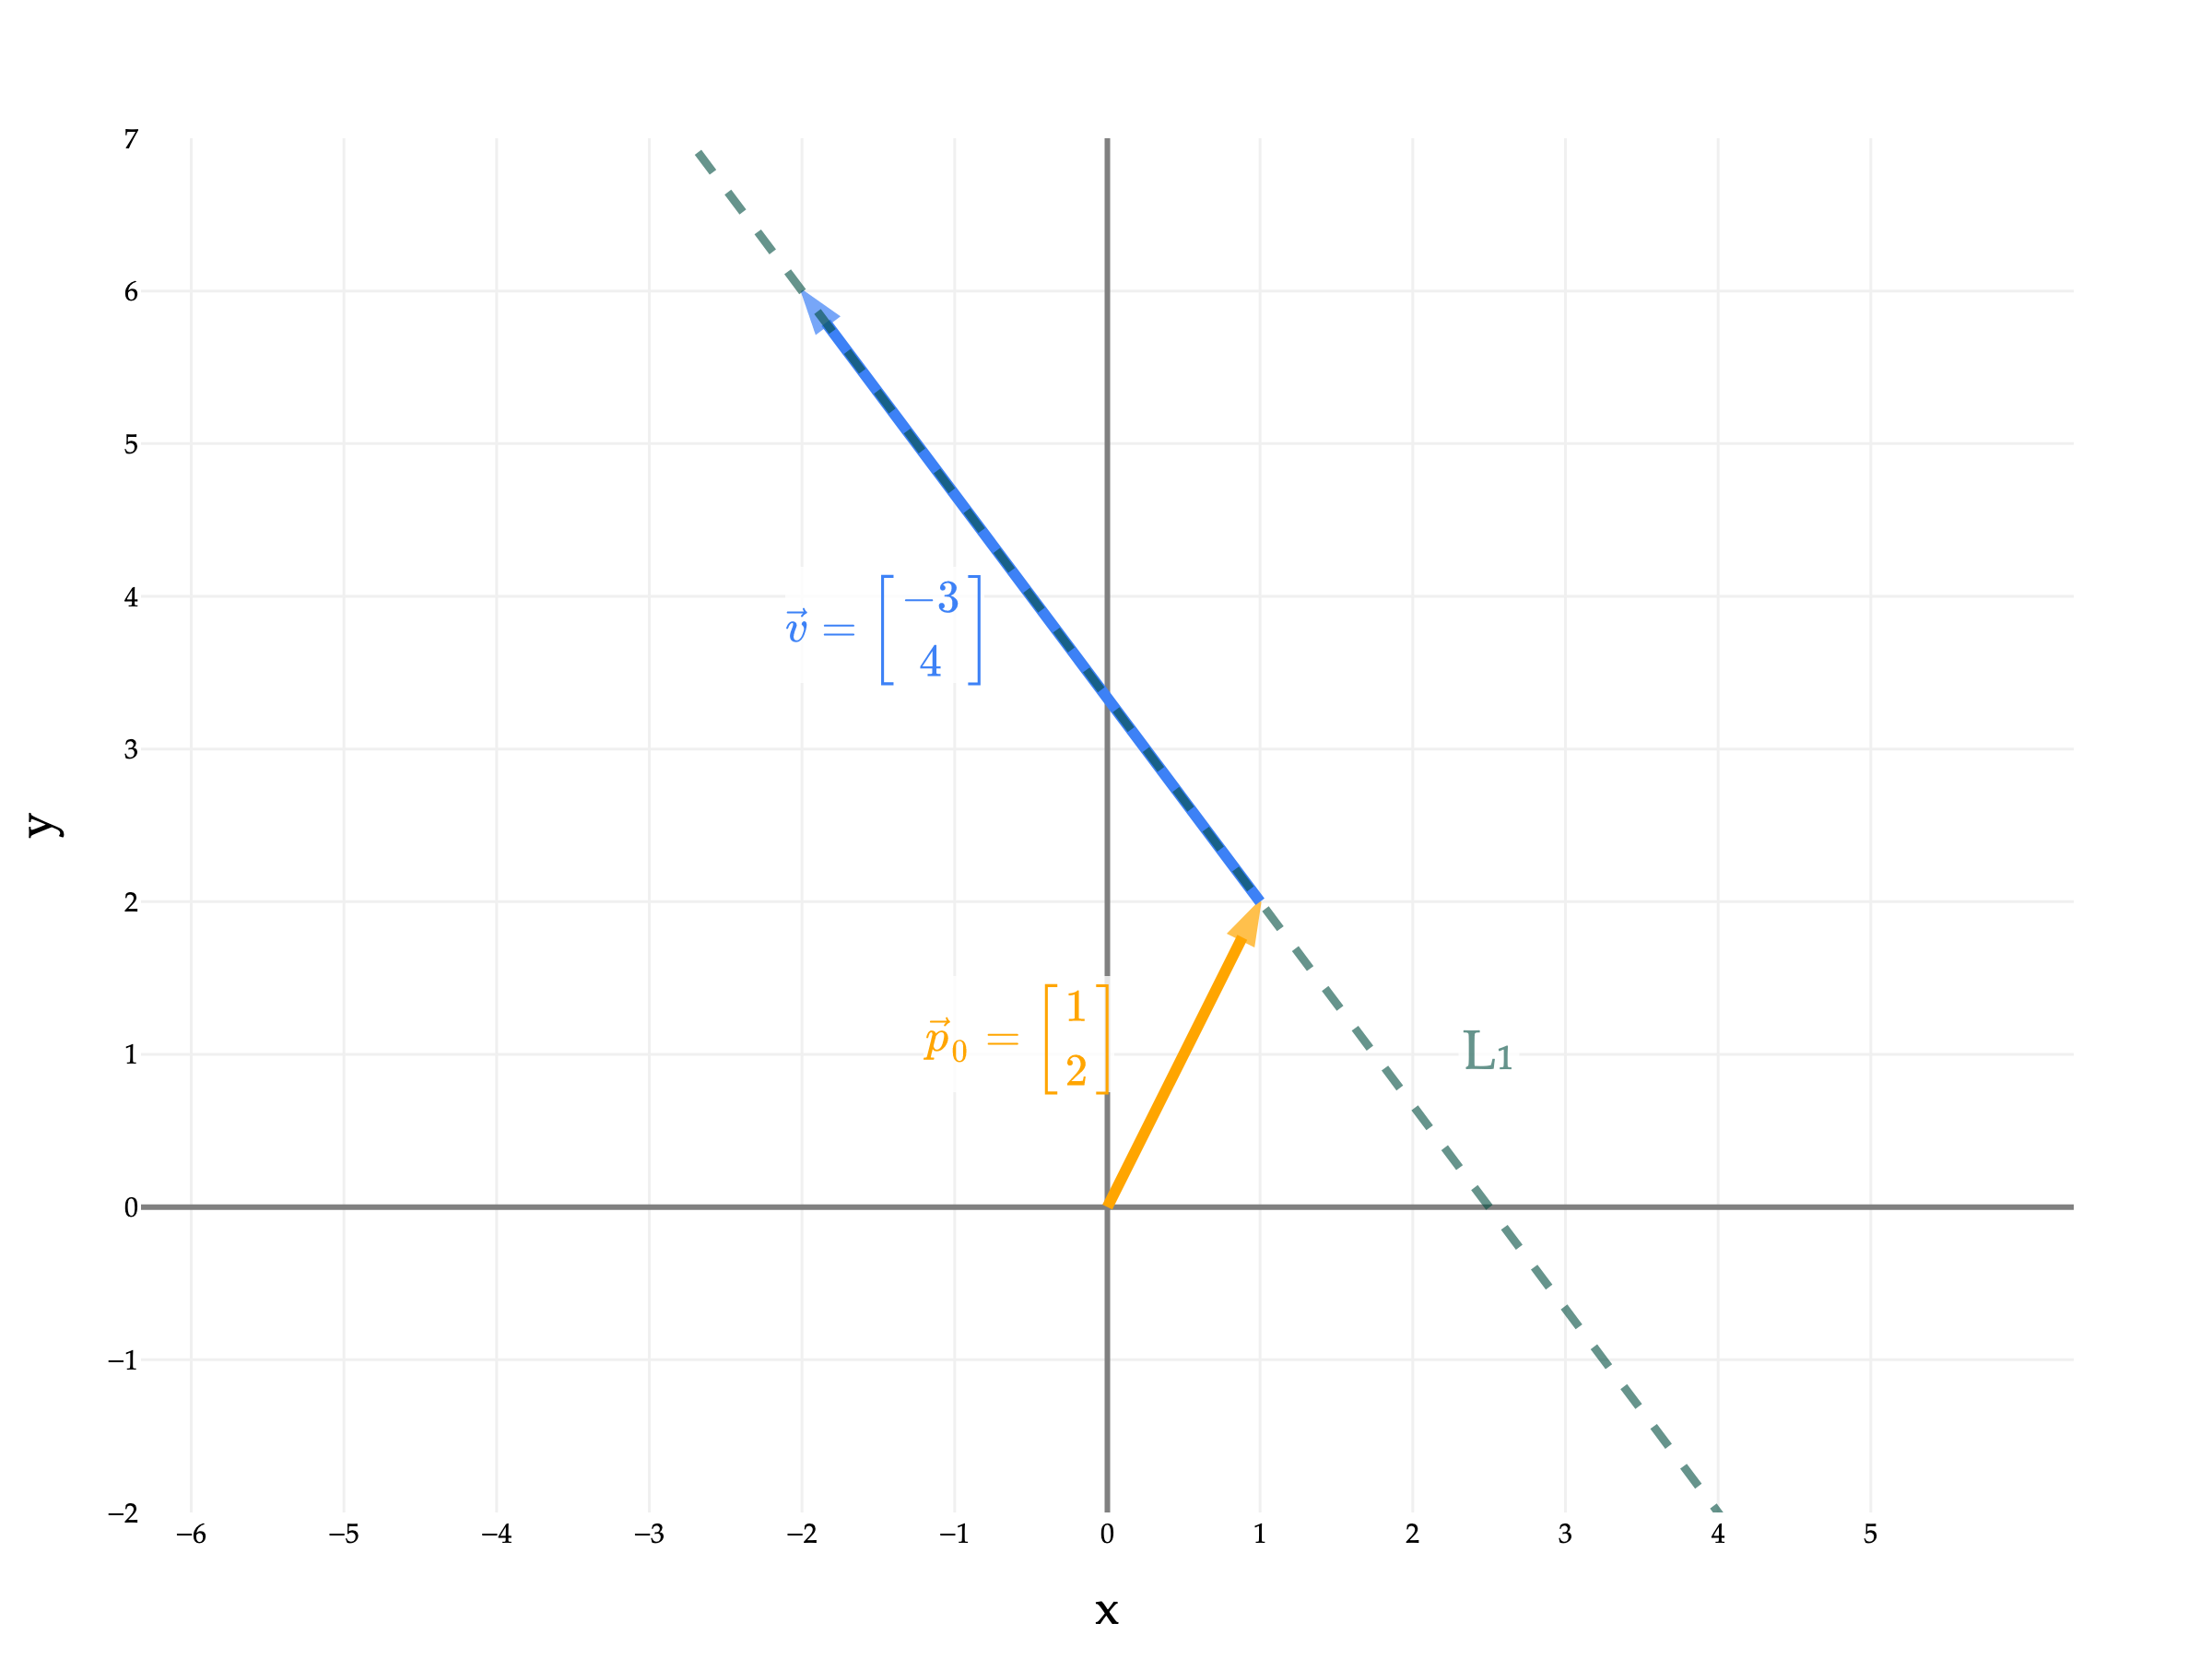

In [24]:
from utils import plot_vectors_non_origin

p0 = (1, 2)
v = (-3, 4)

vectors = [
    # ((start_coords, end_coords), color, label)
    (([0, 0], p0), "orange", r"$\vec p_0 = \begin{bmatrix} 1 \\ 2 \end{bmatrix}$"),
    ((p0, tuple(np.array(p0) + np.array(v))), "#3d81f6", r"$\vec v = \begin{bmatrix} -3 \\ 4 \end{bmatrix}$"),
]

fig = plot_vectors_non_origin(vectors, show_axis_labels=True, vdeltax=1.2)

# Focus the plot on x in [-2, 4]
t = np.linspace(-2, 2, 100)  # Solve for t so that x runs from -2 to 4
line_x = p0[0] + t * v[0]
line_y = p0[1] + t * v[1]

fig.add_trace(
    go.Scatter(
        x=line_x,
        y=line_y,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=3, dash="dash"),
        showlegend=False,
        hoverinfo="skip",
        zorder=0
    ),
)

# This annotation indicates the line represents all possible linear combinations of v alone
fig.add_annotation(
    x=1.5 * v[0] + 7,
    y=1.5 * v[1] - 5,
    text="L₁",
    showarrow=False,
    font=dict(size=20, color="rgba(0,77,64,0.6)"),
    bgcolor="rgba(255,255,255,0.8)"
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    range=[-2, 7]
)

fig.update_xaxes(
    range=[-4, 4],
    tickvals=np.arange(-6, 6, 1)
)

fig.show(renderer='png', scale=3)

And here's $L_2 = \begin{bmatrix} -2 \\ 6 \end{bmatrix} + t \begin{bmatrix} 6 \\ -8 \end{bmatrix}, t \in \mathbb{R}$.

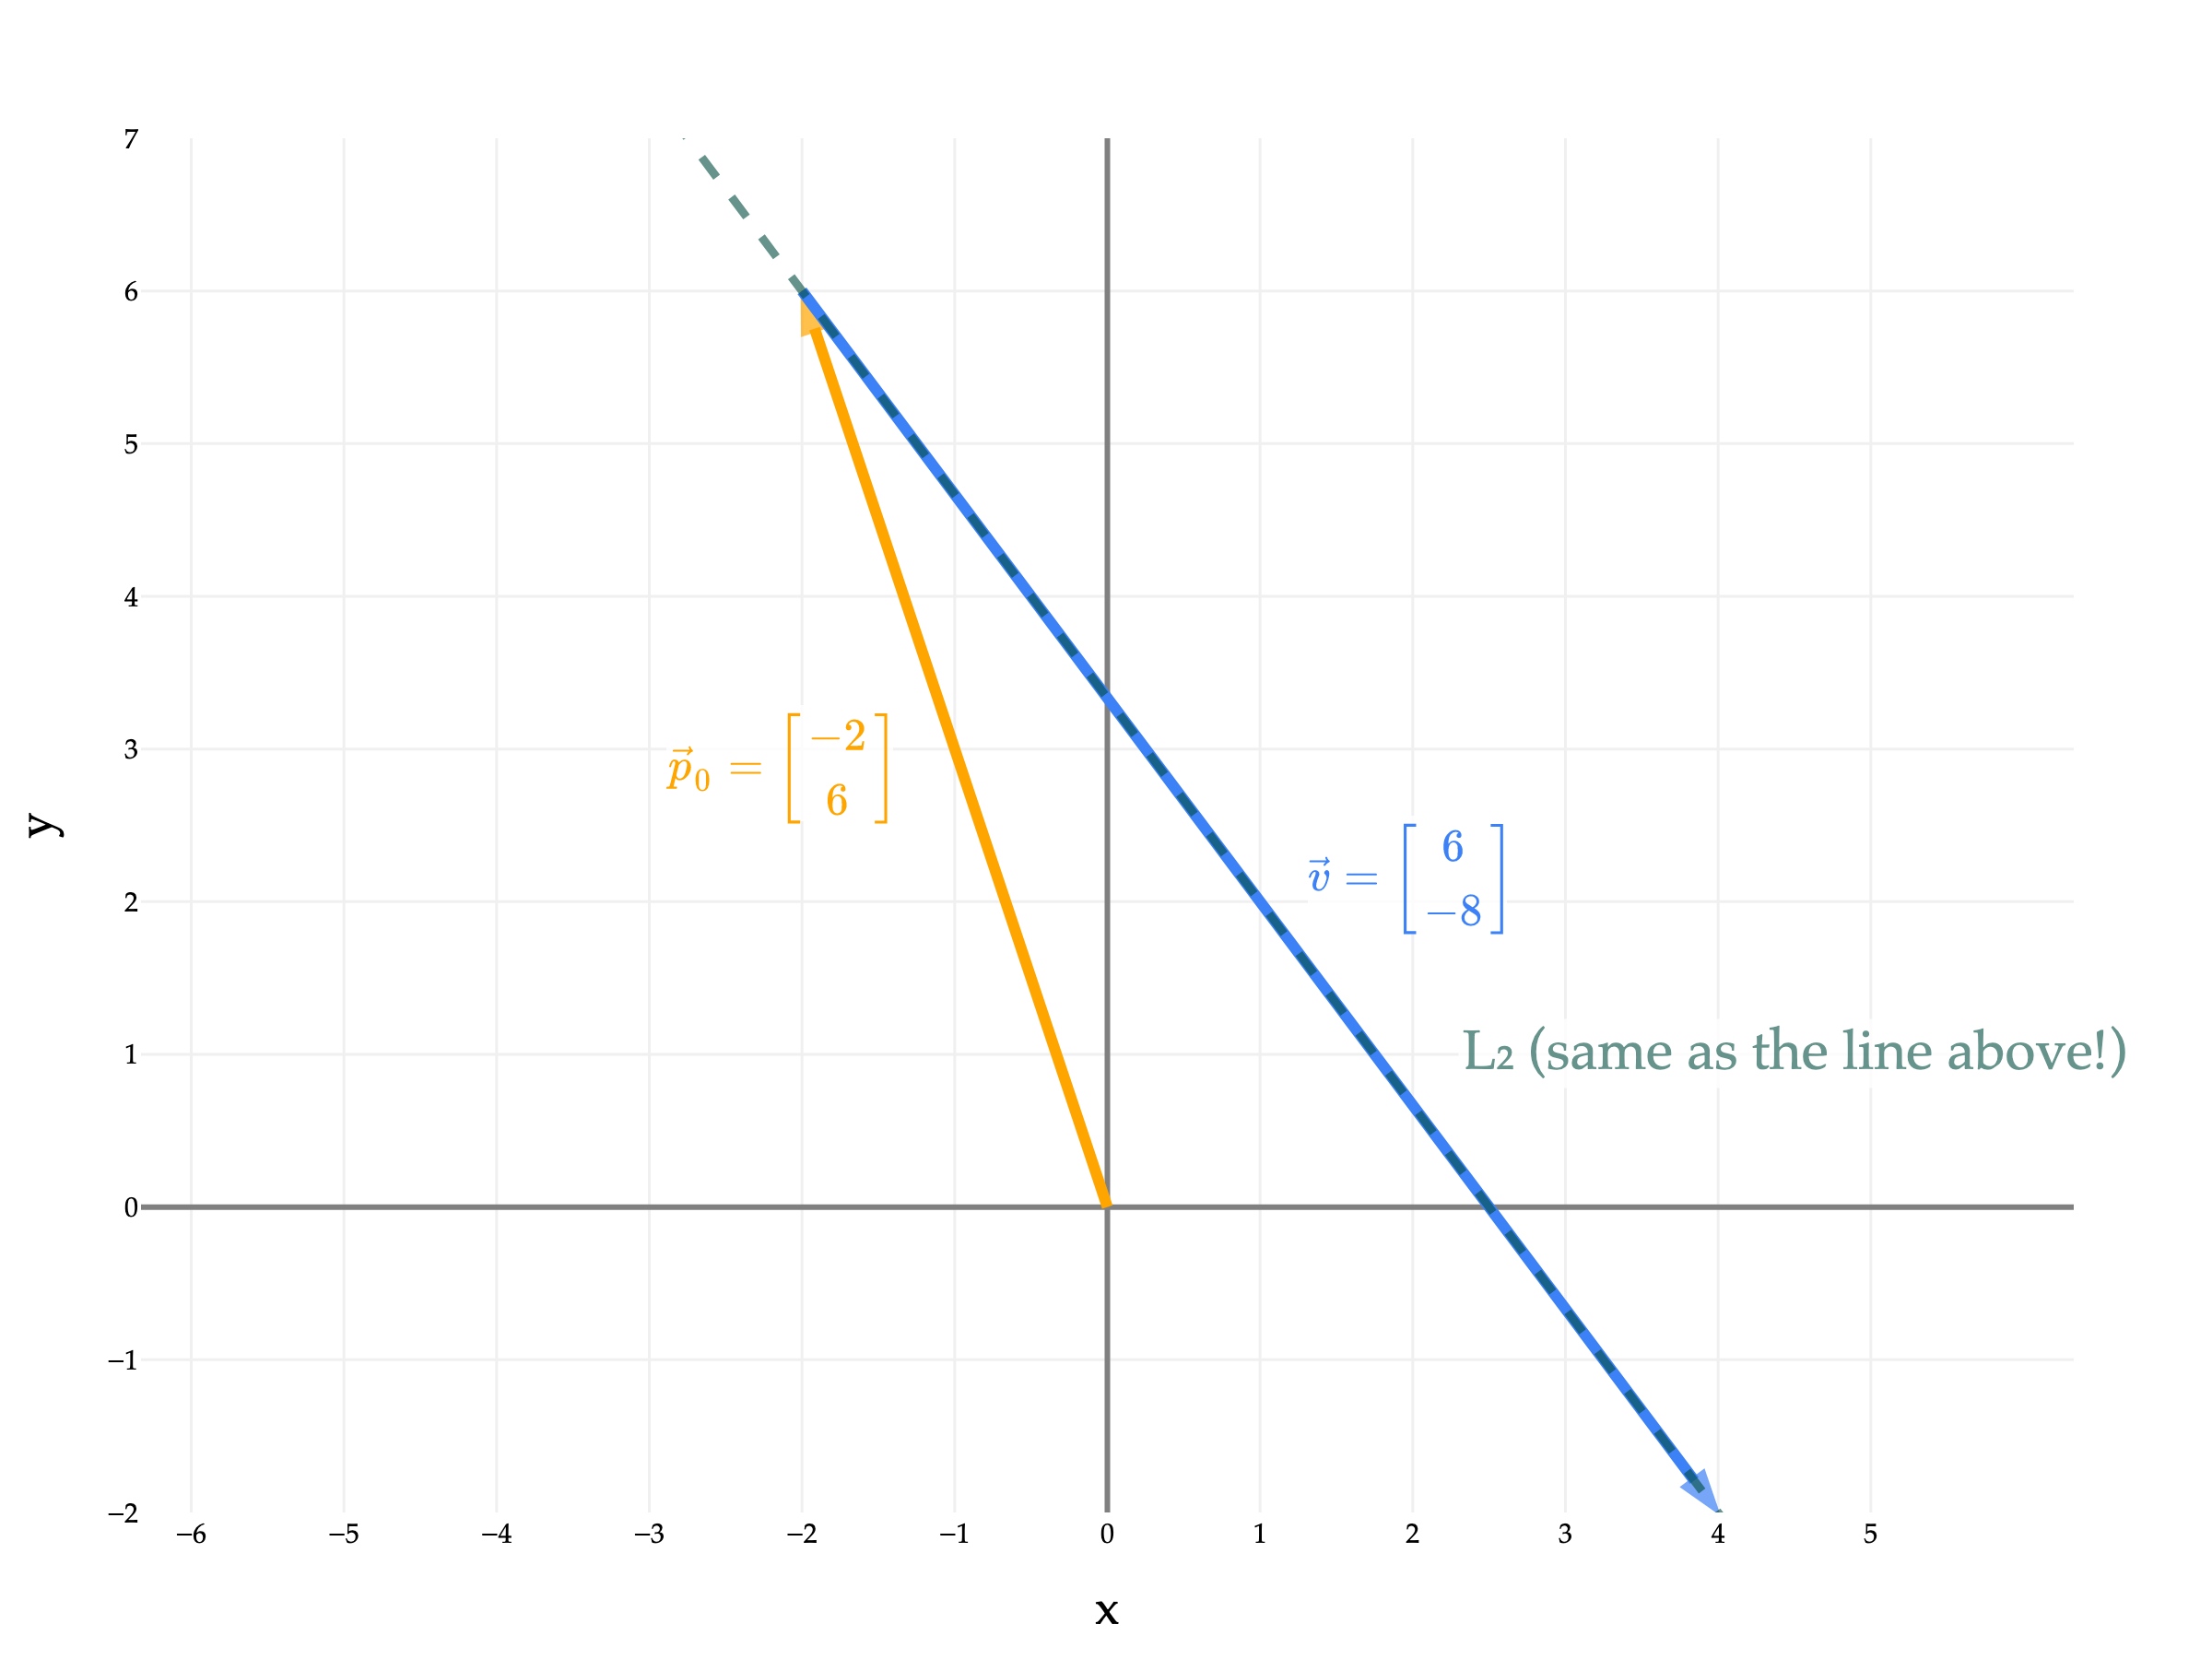

In [25]:
import numpy as np
import plotly.graph_objects as go
from utils import plot_vectors_non_origin

p0 = (-2, 6)
v = (6, -8)

vectors = [
    # ((start_coords, end_coords), color, label)
    (([0, 0], p0), "orange", r"$\vec p_0 = \begin{bmatrix} -2 \\ 6 \end{bmatrix}$"),
    ((p0, tuple(np.array(p0) + np.array(v))), "#3d81f6", r"$\vec v = \begin{bmatrix} 6 \\ -8 \end{bmatrix}$"),
]

fig = plot_vectors_non_origin(vectors, show_axis_labels=True, vdeltax=1.2)

# Focus the plot on x in [-2, 4]
t = np.linspace(-2, 2, 100)  # Solve for t so that x runs from -2 to 4
line_x = p0[0] + t * v[0]
line_y = p0[1] + t * v[1]

fig.add_trace(
    go.Scatter(
        x=line_x,
        y=line_y,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=3, dash="dash"),
        showlegend=False,
        hoverinfo="skip",
        zorder=0
    ),
)

# This annotation indicates the line represents all possible linear combinations of v alone
fig.add_annotation(
    x=4.5,
    y=1,
    text="L₂ (same as the line above!)",
    showarrow=False,
    font=dict(size=20, color="rgba(0,77,64,0.6)"),
    bgcolor="rgba(255,255,255,0.8)"
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    range=[-2, 7]
)

fig.update_xaxes(
    range=[-4, 4],
    tickvals=np.arange(-6, 6, 1)
)

fig.show(renderer='png', scale=3)

Note that we end up with the same line, despite the different starting points and direction vectors!

The proceeding activities give you some practice with the parametric form of a line.

:::{tip} Activity 1
:class: dropdown
Write the line $y = -3x + 5$ in parametric form. There are multiple (infinitely many!) possible answers; give just one. 

:::{seealso} Solution
:class: dropdown

The line above passes through the point $(0, 5)$ and is parallel to the vector $\begin{bmatrix} 1 \\ -3 \end{bmatrix}$, since for every 1 unit we move in the $x$-direction, we move $-3$ units in the $y$-direction. So, the line is:

$$L = \begin{bmatrix} 0 \\ 5 \end{bmatrix} + t \begin{bmatrix} 1 \\ -3 \end{bmatrix}, t \in \mathbb{R}$$

To verify that we got the right line, let's plug in a few values of $t$ and verify that they match the equation $y = -3x + 5$.

- When $t = 0$, we get the point $(0, 5)$, and $-3(0) + 5 = 5$ ✅.
- When $t = 1$, we get the point $(1, 2)$, and $-3(1) + 5 = 2$ ✅.
- When $t = -10$, we get the point $(-10, 35)$, and $-3(-10) + 5 = 35$ ✅.

(We only need to check two points, since if two lines have the same two points, they must be the same line.)

:::

:::{tip} Activity 2
:class: dropdown
Find the equation of the line, in parametric form, of the line in $\mathbb{R}^4$ that passes through the points $(5, -1, 3, 2)$ and $(10, -2, 3, 0)$.

:::{seealso} Solution
:class: dropdown

We know one point on the line; we just need to find a direction vector. One way to do this is to subtract the coordinates of the two points:

$$\begin{bmatrix} 10 \\ -2 \\ 3 \\ 0 \end{bmatrix} - \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} = \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix}$$

So, the line is:

$$L = \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} + t \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix}, t \in \mathbb{R}$$

Plugging in $t = 0$ and $t = 1$ should give us the two points we know are on the line.

:::

:::{tip} Activity 3
:class: dropdown
Could the line you found in Activity 2 be described as the span of a single vector? Why or why not?

:::{seealso} Solution
:class: dropdown

**No**, because it doesn't pass through the origin, and the span of a single vector is always a line that passes through the origin.

Let's look at $L$ once more:

$$L = \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} + t \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix}, t \in \mathbb{R}$$


Just by looking at the equation above, we don't know for a fact that it doesn't pass through the origin, $(0, 0, 0, 0)$. The fixed point that it is defined relative to, $(5, -1, 3, 2)$, is not the origin, but the origin might still be on the line if we pick the right value of $t$.

But, we can verify that that's not the case by plugging in $t = -1$, which gives us a 0 in the first two coordinates, but non-zero values in the other coordinates. At $t = -1$:

$$L = \begin{bmatrix} 5 \\ -1 \\ 3 \\ 2 \end{bmatrix} - 1 \begin{bmatrix} 5 \\ -1 \\ 0 \\ -2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 3 \\ 4 \end{bmatrix}$$

There's no value of $t$ other than $-1$ such that $5 + t(5) = 0$, so no other value of $t$ will give us the point $(0, 0, 0, 0)$.

:::

:::{tip} Activity 4
:class: dropdown
Find the equation of the line, in standard form, that is **orthogonal** to the line

$$3x + 4y + 12 = 0$$

and passes through the point $(9, 5)$.

:::{seealso} Solution
:class: dropdown

What does it mean for two lines to be orthogonal? In $\mathbb{R}^2$ or $\mathbb{R}^3$, it's sufficient to say that they're orthogonal if they intersect at a right angle, because this is an idea we can visualize.

But more generally, we should think of two lines as orthogonal if **their direction vectors are orthogonal** when written in parametric form.

That is, $L_1 = \vec p_0 + t \vec v_1$ and $L_2 = \vec q_0 + s \vec v_2$ are orthogonal if $\vec v_1 \cdot \vec v_2 = 0$. The values of the starting points don't change whether the lines are orthogonal, that just changes where they intersect.

Let's return to our problem, which involves finding a line orthogonal to $3x + 4y + 12 = 0$. What is this line in parametric form? Rearranging it to slope-intercept form gives us

$$y = -\frac{3}{4}x - 3$$

which means that for every 1 unit we move in the $x$-direction, we move $-\frac{3}{4}$ units in the $y$-direction. So, the direction vector of the line is $\begin{bmatrix} 1 \\ -\frac{3}{4} \end{bmatrix}$, or equivalently, $\begin{bmatrix} 4 \\ -3 \end{bmatrix}$ (I multiplied by 4 to get nice numbers in the direction vector; as we saw earlier, any non-zero scalar multiple of a direction vector will give us the same line).

You might notice a general pattern from this: the direction vector for the line $ax + by + c = 0$ is $\begin{bmatrix} b \\ -a \end{bmatrix}$. I'd avoid memorizing this, though, and would rather you derive it from scratch every time (it's not a good use of your memory to memorize this).

We want a line orthogonal to $3x + 4y + 12 = 0$, so we need a direction vector orthogonal to $\begin{bmatrix} 4 \\ -3 \end{bmatrix}$. A natural choice is to create a direction vector of $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$, since $\begin{bmatrix} 3 \\ 4 \end{bmatrix} \cdot \begin{bmatrix} 4 \\ -3 \end{bmatrix} = 0$.

So, in parametric form, one way to express the line we're looking for is

$$L = \begin{bmatrix} 9 \\ 5 \end{bmatrix} + t \begin{bmatrix} 3 \\ 4 \end{bmatrix}, t \in \mathbb{R}$$

But we want our new line in standard form, i.e. $ax + by + c = 0$. To get this, we can look at the direction vector of the new line, $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$ and recognize that it's saying to move 4 units in the $y$-direction for every 3 units we move in the $x$-direction, implying a slope of $\frac{4}{3}$. The new line we're looking for then is $y = \frac{4}{3}x + w_0$, or equivalently $4x - 3y + c = 0$.

To find $c$, we can plug in the point $(9, 5)$ into the equation:

$$4(9) - 3(5) + c = 0 \implies 36 - 15 + c = 0 \implies c = -21$$

So, the line we're looking for is $\boxed{4x - 3y - 21 = 0}$.

You might also notice that the original line $3x + 4y + 12 = 0$ has coefficients of 3 and 4 on $x$ and $y$, and the direction vector of the **line orthogonal to it** is $\begin{bmatrix} 3 \\ 4 \end{bmatrix}$. Keep this in mind, as it'll be useful in the section below on planes.

:::

---

## Planes

Lines are 1-dimensional objects, whether they exist in $\mathbb{R}^2$, or $\mathbb{R}^3$, or $\mathbb{R}^{47}$, or in general $\mathbb{R}^n$.

Similarly, planes are 2-dimensional objects. In $\mathbb{R}^2$, since there only exist two dimensions in the first place, the entirety of the coordinate system is one single plane, which we call the **$xy$-plane**.

Let's start by building intuition for planes in $\mathbb{R}^3$, the most natural setting for them, and then generalize.

### Planes in $\mathbb{R}^3$

:::{note} Definition: Standard Form of a Plane in $\mathbb{R}^3$

A plane in $\mathbb{R}^3$ is the set of all points $(x, y, z)$ that satisfy the equation

$$ax + by + cz + d = 0$$

where $a, b, c, d \in \mathbb{R}$.

Note that the above equation can also be written in the form

$$z = Ax + By + C$$

where $A = -\frac{a}{c}$, $B = -\frac{b}{c}$, and $C = -\frac{d}{c}$.
:::

For example, let's draw:
1. $\color{#3d81f6} 3x + 4y - 5z - 12 = 0$, or equivalently $z = \frac{3}{5}x + \frac{4}{5}y + \frac{12}{5}$
2. $\color{orange} -5x - 3y - z = 0$, or equivalently $z = -5x - 3y$

You'll notice that they intersect at a line. This is not a coincidence; any two **non-parallel** planes in $\mathbb{R}^3$ will intersect at a line.

In [26]:
from hw04_util import draw_equations

fig = draw_equations([[3, 4, -5, -12], [-5, -3, -1, 0]])
fig.show()

Note that both planes are flat surfaces **that extend infinitely in all directions**. The fact that the <span style="color: #3d81f6; font-weight: bold">blue plane</span> is cut off at the edges is just due to how I'm plotting the planes, **not** that there's some boundary within which the plane is defined.

You'll notice that the <span style="color: #3d81f6; font-weight: bold">blue plane</span> is relatively shallow, while the <span style="color: orange; font-weight: bold">orange plane</span> is relatively steep. Why?

I find the form $z = Ax + By + C$ easier to understand intuitively, since it shows the rate of change of $z$ with respect to $x$ and $y$ more clearly. Starting with $z = Ax + By + C$, we have that

$$\frac{\partial z}{\partial x} = A, \quad \frac{\partial z}{\partial y} = B$$

In this example, the <span style="color: #3d81f6; font-weight: bold">blue plane</span> has $A = \frac{3}{5}$ and $B = \frac{4}{5}$, while the <span style="color: orange; font-weight: bold">orange plane</span> has $A = -5$ and $B = -3$, which explains their relative steepness.

That said, be careful, since a plane need not have a non-zero coefficient on $z$. For example, $3x + 4y = 0$ and $3x + 4y = 5$ is are perfectly valid planes, and they happen to be parallel.

In [27]:
draw_equations([[3, 4, 0, 0], [3, 4, 0, 5]])

A key property of planes is that they are **flat**. Sure, we know that intuitively, but what does it actually mean?

:::{attention} Planes Contain all Secant Lines
Recall from [Appendix 2](../00_math_foundations/02-derivatives.ipynb) that a **secant line** is a line that connects two points on the graph of a function.

A key property of planes is that **if you pick any two points on the plane, the secant line connecting them is entirely on the plane**. This is true for planes in any $\mathbb{R}^n$, not just planes in $\mathbb{R}^3$.
:::

This property is not true in general for other surfaces.

In [44]:
import numpy as np
import plotly.graph_objects as go

# --- Plot 1: Plane with secant line ---

def plane_z(x, y):
    return (3*x + 4*y - 12)/5

p1 = np.array([1, 1, plane_z(1, 1)])
p2 = np.array([3, -2, plane_z(3, -2)])

xx, yy = np.meshgrid(np.linspace(-2, 4, 20), np.linspace(-3, 3, 20))
zz = plane_z(xx, yy)

plane_trace = go.Surface(
    x=xx, y=yy, z=zz,
    colorscale=[[0, '#3d81f6'], [1, '#3d81f6']],
    opacity=0.7, showscale=False
)

secant_trace = go.Scatter3d(
    x=[p1[0], p2[0]],
    y=[p1[1], p2[1]],
    z=[p1[2], p2[2]],
    mode='lines+markers',
    line=dict(color='black', width=6),
    marker=dict(size=6, color='black'),
    name='Secant Line'
)

fig1 = go.Figure(data=[plane_trace, secant_trace])
fig1.update_layout(
    title="",
    scene=dict(
        xaxis_title='x', yaxis_title='y', zaxis_title='z',
        aspectmode='cube',
        xaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        yaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        zaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Palatino, serif')
)

# --- Plot 2: Curved surface with secant line ---

def surf_z(x, y):
    return x**2 + y**2

q1 = np.array([1, 1, surf_z(1, 1)])
q2 = np.array([-1, -2, surf_z(-1, -2)])

xx2, yy2 = np.meshgrid(np.linspace(-2, 2, 40), np.linspace(-2, 2, 40))
zz2 = surf_z(xx2, yy2)

surf_trace = go.Surface(
    x=xx2, y=yy2, z=zz2,
    colorscale=[[0, 'orange'], [1, 'orange']],
    opacity=0.7, showscale=False
)

secant_trace2 = go.Scatter3d(
    x=[q1[0], q2[0]],
    y=[q1[1], q2[1]],
    z=[q1[2], q2[2]],
    mode='lines+markers',
    line=dict(color='black', width=6),
    marker=dict(size=6, color='black'),
    name='Secant Line'
)

fig2 = go.Figure(data=[surf_trace, secant_trace2])
fig2.update_layout(
    title="Not a plane: Secant lines may be above or below the surface",
    scene=dict(
        xaxis_title='x', yaxis_title='y', zaxis_title='z',
        aspectmode='cube',
        xaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        yaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0'
        ),
        zaxis=dict(
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
        ),
    ),
    margin=dict(l=0, r=0, b=0, t=30),
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Palatino, serif')
)

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=("Plane: Any secant line is<br><b>entirely</b> on the plane", "Not a plane: Secant lines<br> may be above or below<br>the surface"),
    horizontal_spacing=0
)

for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)
for trace in fig2.data:
    fig.add_trace(trace, row=1, col=2)

fig.update_layout(
    height=350, width=700,
    showlegend=False,
    margin=dict(l=0, r=0, b=30, t=80),
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Palatino, serif')
)

# Update both scenes for grid and background
fig.update_scenes(
    xaxis=dict(
        backgroundcolor='white',
        gridcolor='#f0f0f0',
        zerolinecolor='#f0f0f0'
    ),
    yaxis=dict(
        backgroundcolor='white',
        gridcolor='#f0f0f0',
        zerolinecolor='#f0f0f0'
    ),
    zaxis=dict(
        backgroundcolor='white',
        gridcolor='#f0f0f0',
        zerolinecolor='#f0f0f0',
    )
)

fig.show()

### The Cross Product

I first mentioned planes back in [Chapter 3.1](../03_vectors/01-vectors-and-linear-combinations.ipynb), when we intuitively discussed the fact that the set of all linear combinations of two non-collinear vectors in $\mathbb{R}^3$ forms a plane. We discussed this idea at length in [Chapter 4.1](./01-span.ipynb), too.

So, given two vectors ${\color{orange} \vec u = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix}}, {\color{#3d81f6} \vec v = \begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix}} \in \mathbb{R}^3$, how do we find the equation of the plane they span, in standard form?

In [50]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (5, 2, 1)
v2 = (-2, 3, 0)

fig = plot_vectors([(v1, "orange", r"u"), 
                    (v2, "#3d81f6", r"v"),
                    ], show_axis_labels=True, vdeltax=0.3, vdeltay=1)

# Add the plane spanned by v1 and v2
plane_extent = 20
num_points = 3

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
    showscale=False,
))

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    xaxis_range=[-10, 10],
    yaxis_range=[-10, 10],
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    scene=dict(
        aspectmode='cube',
    ),
)

fig.show()

The standard form of a plane in $\mathbb{R}^3$ is $$ax + by + cz + d = 0$$ We know that the plane spanned by two vectors in $\mathbb{R}^3$ must contain the zero vector, since $0{\color{orange} \vec u} + 0{\color{#3d81f6} \vec v} = \vec 0$. This means that the point $(x, y, z) = (0, 0, 0)$ must satisfy the equation of the plane. Plugging in $(x, y, z) = (0, 0, 0)$ into $ax + by + cz + d = 0$ gives us $d = 0$.

So, I'm searching for a plane of the form $ax + by + cz = 0$. Plugging in $\color{orange} \vec u = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix}$ tells me that $a$, $b$, and $c$ must satisfy

$$a{\color{orange} u_1} + b{\color{orange} u_2} + c{\color{orange} u_3} = 0$$

Similarly, $a$, $b$, and $c$ must also satisfy

$$a{\color{#3d81f6} v_1} + b{\color{#3d81f6} v_2} + c{\color{#3d81f6} v_3} = 0$$

Look closely. The left-hand side of both equations looks a lot like the dot product of $\begin{bmatrix} a \\ b \\ c \end{bmatrix}$ with each of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$. Since those dot products must both be 0 (coming from the right-hand side of each equation), we're really just looking for a vector $\begin{bmatrix} a \\ b \\ c \end{bmatrix}$ that's orthogonal to both $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$.

There are infinitely many vectors orthogonal to a particular pair of vectors $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$, meaning there are infinitely many possible values of $a$, $b$, and $c$ that satisfy the above equations. (There are 2 equations but 3 unknowns, so we'd expect there to be infinitely many solutions.) 

But, one property that all of these vectors share is that they all point in the same direction – if $\begin{bmatrix} a \\ b \\ c \end{bmatrix}$ is orthogonal to $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$, then so is any non-zero scalar multiple of $\begin{bmatrix} a \\ b \\ c \end{bmatrix}$.

In [54]:
from utils import plot_vectors
import numpy as np
import plotly.graph_objects as go

v1 = (5, 2, 1)
v2 = (-2, 3, 0)

fig = plot_vectors([(v1, "orange", r"u"), 
                    (v2, "#3d81f6", r"v"),
                    ], show_axis_labels=True, vdeltax=1, vdeltay=1)

# Add the plane spanned by v1 and v2
plane_extent = 20
num_points = 3

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.3)'], [1, 'rgba(61,129,246,0.3)']],
    showscale=False,
))

# Compute the cross product of v1 and v2
v1_arr = np.array(v1)
v2_arr = np.array(v2)
cross = np.cross(v1_arr, v2_arr)

# Draw the line spanned by the cross product through the origin as a dotted line
line_extent = 10
line_points = np.linspace(-line_extent, line_extent, 2)
line_x = line_points * cross[0]
line_y = line_points * cross[1]
line_z = line_points * cross[2]

fig.add_trace(
    go.Scatter3d(
        x=line_x,
        y=line_y,
        z=line_z,
        mode="lines",
        line=dict(color="rgba(0,77,64,0.6)", width=3, dash="dot"),
        showlegend=False,
        hoverinfo="skip"
    ),
)
# Add annotation at the midpoint of the line in the same color
mid_idx = len(line_points) // 2
fig.add_trace(
    go.Scatter3d(
        x=[5],y=[5],z=[5],
        mode="text",
        text=["All vectors orthogonal to u and v lie on this line"],
        textposition="top center",
        textfont=dict(color="rgba(0,77,64,0.9)", size=14),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.update_xaxes(
    scaleanchor="y",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_yaxes(
    scaleanchor="x",
    scaleratio=1,
    tickvals=np.arange(-10, 10, 1)
)

fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10, 10]),
        yaxis=dict(range=[-10, 10]),
        zaxis=dict(range=[-10, 10]),
        aspectmode='cube',
    ),
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
)

fig.show()

One particular vector (i.e. set of coefficients $a$, $b$, and $c$) that satisfies the above equations is the **cross product** of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$. 

:::{note} Definition: Cross Product
Suppose ${\color{orange} \vec u = \begin{bmatrix} u_1 \\ u_2 \\ u_3 \end{bmatrix}}$ and ${\color{#3d81f6} \vec v = \begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix}}$ are in $\mathbb{R}^3$. (Note that the cross product is only defined for two vectors in $\mathbb{R}^3$!)

Then, the cross product of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ is given by

$${\color{orange} \vec u} \times {\color{#3d81f6} \vec v} = \begin{bmatrix} {\color{orange} u_2}{\color{#3d81f6} v_3}- {\color{orange} u_3}{\color{#3d81f6} v_2} \\ {\color{orange} u_3}{\color{#3d81f6} v_1} - {\color{orange} u_1}{\color{#3d81f6} v_3} \\ {\color{orange} u_1}{\color{#3d81f6} v_2} - {\color{orange} u_2}{\color{#3d81f6} v_1} \end{bmatrix}$$
:::

There's a lot of meaning baked into the definition of the cross product, but most of it is more relevant in a traditional engineering or physics context. For example, the cross product is **anticommutative**, meaning that the order you compute it in matters. $${\color{orange} \vec u} \times {\color{#3d81f6} \vec v} = -({\color{#3d81f6} \vec v} \times {\color{orange} \vec u})$$

That's the type of statement we won't bother investigating further here. The key fact that is relevant for us right now is that the vector ${\color{orange} \vec u} \times {\color{#3d81f6} \vec v}$ is orthogonal to both $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$.

:::{tip} Activity 5
:class: dropdown
Verify that the cross product of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ is orthogonal to both $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$.
:::

:::{tip} Activity 6
:class: dropdown
Suppose $\vec u, \vec v, \vec w$ are non-zero vectors in $\mathbb{R}^3$. Show that $\vec u, \vec v, \vec w$ are linearly independent if and only if $(\vec u \times \vec v) \cdot \vec w \neq 0$.

:::

Let's use the cross product to concretely find the equation of the plane planned by two vectors in $\mathbb{R}^3$. Suppose $\color{orange} \vec u = \begin{bmatrix} 5 \\ 2 \\ 1 \end{bmatrix}$ and $\color{#3d81f6} \vec v = \begin{bmatrix} -2 \\ 3 \\ 0 \end{bmatrix}$.

The cross product of $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ is given by

$${\color{orange} \vec u} \times {\color{#3d81f6} \vec v} = \begin{bmatrix} {\color{orange}2} \cdot {\color{#3d81f6}0} - {\color{orange}1} \cdot {\color{#3d81f6}3} \\ {\color{orange}1} \cdot {\color{#3d81f6}(-2)} - {\color{orange}5} \cdot {\color{#3d81f6}0} \\ {\color{orange}5} \cdot {\color{#3d81f6}3} - {\color{orange}2} \cdot {\color{#3d81f6}(-2)} \end{bmatrix} = \begin{bmatrix} -3 \\ -2 \\ 19 \end{bmatrix}$$

The equation of the plane spanned by $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ is then given by

$$-3x - 2y + 19z = 0$$

The vector that the cross product returns is sometimes called the **normal vector** of the plane. Normal is another term for orthogonal or perpendicular. For the plane $-3x - 2y + 19z = 0$, the normal vector is $\begin{bmatrix} -3 \\ -2 \\ 19 \end{bmatrix}$, as that vector is orthogonal to the two vectors $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ that span the plane. When we're looking at the standard form of the equation of a plane in $\mathbb{R}^3$, the normal vector is just the coefficients of $x$, $y$, and $z$ in the equation $ax + by + cz = 0$.

There are infinitely many normal vectors for a given plane, since we can multiply any normal vector by a scalar and still get a normal vector. For example, $\begin{bmatrix} -3 \\ -2 \\ 19 \end{bmatrix}$ is a normal vector for the plane $-3x - 2y + 19z = 0$, and so is $\begin{bmatrix} -6 \\ -4 \\ 38 \end{bmatrix}$ and $\begin{bmatrix} 1 \\ 2/3 \\ -19/3 \end{bmatrix}$. Equivalently, $-6x - 4y + 38z = 0$ and $x + \frac{2}{3}y - \frac{19}{3}z = 0$ are ways to write the same plane we've been looking at.

:::{tip} Activity 7
:class: dropdown
1. Find the equation, in standard form, of the plane spanned by $\begin{bmatrix} 3 \\ 2 \\ 0 \end{bmatrix}$ and $\begin{bmatrix} -1 \\ 1 \\ 0 \end{bmatrix}$. Why did you not need to compute the cross product?
1. Find the equation, in standard form, of the plane spanned by $\begin{bmatrix} 3 \\ 2 \\ 4 \end{bmatrix}$ and $\begin{bmatrix} -1 \\ 1 \\ 2 \end{bmatrix}$.
:::

### Planes in Parametric Form

The cross product is a construct that only exists in 3-dimensions. Why is that? The cross product relies on the fact that the vectors $\color{orange} \vec u$ and $\color{#3d81f6} \vec v$ are linearly independent, meaning they span a plane, and that there is **only one direction** in $\mathbb{R}^3$ that is orthogonal to that plane. The cross product returns a vector in that direction. But, given two vectors in $\mathbb{R}^4$, for instance, there are infinitely many directions that are orthogonal to both of those two vectors, so it's hard to think of an operation that returns any one of them.

All of that is to say, in $\mathbb{R}^4$ and above, we can't express planes in standard form, the same way we can't express lines in $\mathbb{R}^3$ in standard form. Instead, we'll need to resort to their parametric form.

:::{note} Definition: Parametric Form of a Plane

A plane in $\mathbb{R}^n$, $n \geq 3$, can be described as the set of all points $(x_1, x_2, \ldots, x_n)$ that can be written as

$$P = \vec p_0 + s\vec u + t\vec v, \quad s, t \in \mathbb{R}$$

where $\vec p_0, \vec u, \vec v \in \mathbb{R}^n$. $\vec p_0$ is a point on the plane, and $\vec u$ and $\vec v$ are two **linearly independent** direction vectors.
:::

Again, the formal way of stating this definition is to treat the plane like a set of points that obeys an inclusion condition.

$$P = \left\{ \vec p_0 + s\vec u + t\vec v \mid s, t \in \mathbb{R} \right\}$$

This definition is very similar to the definition of the parametric form of a line in $\mathbb{R}^n$, it's just that instead of one direction vector, we have two. For instance,

$$P = \begin{bmatrix} 3 \\ 8 \\ 1 \\ 2 \\ -7 \\ \pi \end{bmatrix} + s\begin{bmatrix} 1 \\ 0 \\ 2 \\ -1 \\ 0 \\ 0 \end{bmatrix} + t\begin{bmatrix} 5 \\ 2 \\ -1 \\ 3 \\ 1 \\ 0 \end{bmatrix}$$

is a plane in $\mathbb{R}^6$, and you should think of it as a 2-dimensional "slice" of 6-dimensional space.

:::{tip} Activity 8
:class: dropdown
What would happen if the two direction vectors that define a plane weren't linearly independent?
:::

:::{tip} Activity 9
:class: dropdown
Prove that if you pick any two points on a plane in $\mathbb{R}^n$, the line connecting the two points is contained entirely on the plane.

_Hint: Start by picking two points on the plane. Both of them must satisfy the parametric equation above, just with different values of $s$ and $t$. Then, using what you've learned about parametric equations of lines, find the equation of the line connecting the two. What do you notice about that line?_
:::

:::{tip} Activity 10
:class: dropdown
Consider the points $(3, 4, 5)$, $(1, 9, -2)$, and $(2, 2, 0)$. Find the equation of the plane that passes through all three points, and express that plane in both parametric form and standard form, $ax + by + cz + d = 0$.

:::{seealso} Solution
:class: dropdown

Start by picking one of the three points; we'll use $(3, 4, 5)$. Then, subtract this point from the other two points to find two direction vectors on the plane:

$$\vec u = \begin{bmatrix} 1 \\ 9 \\ -2 \end{bmatrix} - \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix} = \begin{bmatrix} -2 \\ 5 \\ -7 \end{bmatrix}$$

$$\vec v = \begin{bmatrix} 2 \\ 2 \\ 0 \end{bmatrix} - \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix} = \begin{bmatrix} -1 \\ -2 \\ -5 \end{bmatrix}$$

So, the plane in parametric form is

$$P = \begin{bmatrix} 3 \\ 4 \\ 5 \end{bmatrix} + s\begin{bmatrix} -2 \\ 5 \\ -7 \end{bmatrix} + t\begin{bmatrix} -1 \\ -2 \\ -5 \end{bmatrix}, \quad s,t \in \mathbb{R}$$

To find the standard form, compute the cross product of the two direction vectors:

$$\vec u \times \vec v = \begin{bmatrix} 5(-5) - (-7)(-2) \\ (-7)(-1) - (-2)(-5) \\ (-2)(-2) - 5(-1) \end{bmatrix} = \begin{bmatrix} -39 \\ -3 \\ 9 \end{bmatrix}$$

This gives a vector orthogonal to the plane, so the plane has the form

$$-39x - 3y + 9z + d = 0$$

Plug in $(3,4,5)$ to solve for $d$:

$$-39(3) - 3(4) + 9(5) + d = 0$$

$$-117 - 12 + 45 + d = 0$$

$$d = 84$$

So, one standard-form equation is

$$-39x - 3y + 9z + 84 = 0$$

Equivalently, dividing by $-3$ gives

$$\boxed{13x + y - 3z - 28 = 0}$$
:::

---

## Hyperplanes

So far, we've learned how to think of lines and planes in arbitrarily high dimensions. We can't visualize a plane in $\mathbb{R}^{76}$, but we have some intuition that it's a 2-dimensional "slice" of 76-dimensional space.

On the topic of slices:
- A line is a **1**-dimensional "slice" of 2-dimensional space.
- A plane is a **2**-dimensional "slice" of 3-dimensional space.

In general, a **hyperplane** is an $(n-1)$-dimensional "slice" of $n$-dimensional space.

:::{note} Definition: Hyperplane

A **hyperplane** in $\mathbb{R}^n$ is the set of all points $(x_1, x_2, \ldots, x_n)$ that satisfy the equation

$$a_1x_1 + a_2x_2 + \cdots + a_nx_n + b = \vec a \cdot \vec x + b = 0$$

where $\vec a, \vec x \in \mathbb{R}^n$ and $b \in \mathbb{R}$.
:::

The most common way of representing a hyperplane is the form $\vec a \cdot \vec x + b = 0$.

- **Example**: $2x_1 + 3x_2 - 5 = 0 $ is a hyperplane in $\mathbb{R}^2$, defined by the vector $\vec a = \begin{bmatrix} 2 \\ 3 \end{bmatrix}$ and $b = -5$. This is just a line in $\mathbb{R}^2$. (If it helps to see that this is a line, relabel $x_1$ and $x_2$ as $x$ and $y$.)
- **Example**: $x_1 + x_2 + x_3 = 0$ is a hyperplane in $\mathbb{R}^3$, defined by the vector $\vec a = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix}$ and $b = 0$. This is just a plane in $\mathbb{R}^3$.

Hyperplanes are **hugely** important in machine learning, particularly in the context of **classification**. You should think of a hyperplane in $\mathbb{R}^n$ as a boundary that divides all of $\mathbb{R}^n$ into two halves: everything is either above it or below it.

For example, the hyperplane $\begin{bmatrix} -3 \\ -2 \\ 19 \end{bmatrix} \cdot \vec x = 0$ is shown below. Any point in $\mathbb{R}^3$ is either above it, meaning $\begin{bmatrix} -3 \\ -2 \\ 19 \end{bmatrix} \cdot \vec x > 0$, or below it, meaning $\begin{bmatrix} -3 \\ -2 \\ 19 \end{bmatrix} \cdot \vec x < 0$. (Yes, this hyperplane is just the plane $-3x - 2y + 19z = 0$ from earlier!)

In [7]:
import numpy as np
import plotly.graph_objects as go

v1 = (5, 2, 1)
v2 = (-2, 3, 0)

plane_extent = 20
num_points = 3

s_range = np.linspace(-plane_extent, plane_extent, num_points)
t_range = np.linspace(-plane_extent, plane_extent, num_points)
s_grid, t_grid = np.meshgrid(s_range, t_range)

plane_x = s_grid * v1[0] + t_grid * v2[0]
plane_y = s_grid * v1[1] + t_grid * v2[1]
plane_z = s_grid * v1[2] + t_grid * v2[2]

fig = go.Figure()

fig.add_trace(go.Surface(
    x=plane_x,
    y=plane_y,
    z=plane_z,
    opacity=0.8,
    colorscale=[[0, 'rgba(61,129,246,0.8)'], [1, 'rgba(61,129,246,0.8)']],
    showscale=False,
))

fig.update_layout(
    scene=dict(
        xaxis=dict(
            range=[-10, 10],
            title='x₁',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
            # tickfont=dict(family='Palatino'),
            # titlefont=dict(family='Palatino')
        ),
        yaxis=dict(
            range=[-10, 10],
            title='x₂',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
            # tickfont=dict(family='Palatino'),
            # titlefont=dict(family='Palatino')
        ),
        zaxis=dict(
            range=[-10, 10],
            title='x₃',
            backgroundcolor='white',
            gridcolor='#f0f0f0',
            zerolinecolor='#f0f0f0',
            showbackground=True,
            # tickfont=dict(family='Palatino'),
            # titlefont=dict(family='Palatino')
        ),
        aspectmode='cube',
    ),
    width=600,
    height=600,
    scene_camera=dict(
        eye=dict(x=-1.2, y=2, z=1.2)
    ),
    font=dict(family='Palatino'),
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()

Another more concrete example of a hyperplane comes from looking at the diabetes classification problem first introduced in Homework 3. There, we explored a dataset of several patients, each of which had two features – a glucose level and a body mass index (BMI) – along with a binary label indicating whether they have diabetes or not.

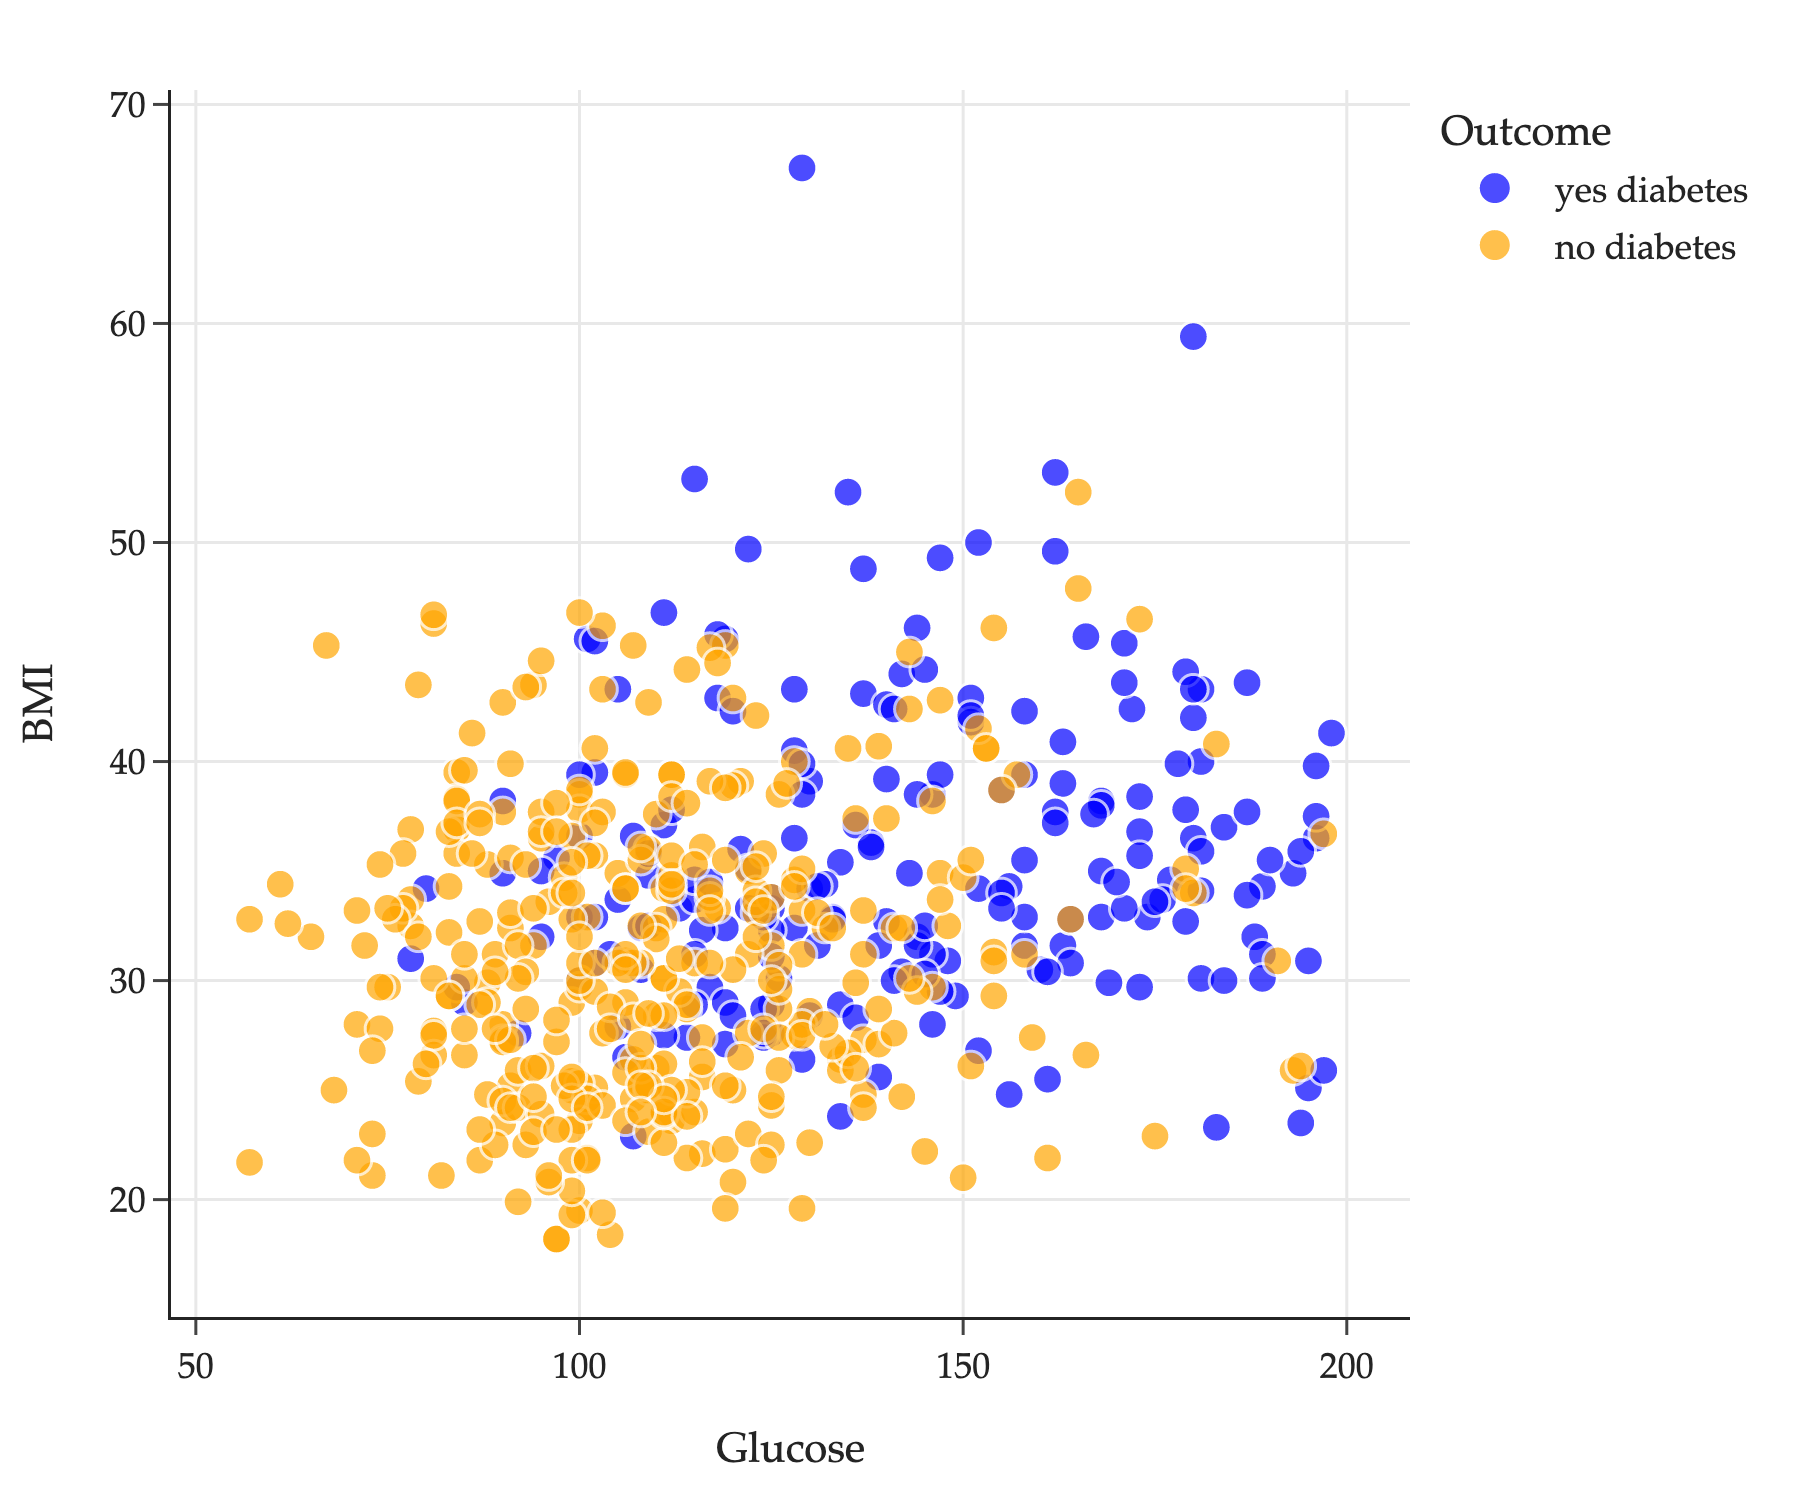

In [10]:
import os
import sys

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

ASSET_DIR = os.path.join('hyperplane-ex')
if ASSET_DIR not in sys.path:
    sys.path.append(ASSET_DIR)
import util

diabetes = pd.read_csv(os.path.join(ASSET_DIR, 'data', 'diabetes.csv'))
X_train, X_test, y_train, y_test = train_test_split(
    diabetes[['Glucose', 'BMI']], diabetes['Outcome'], random_state=1
)

fig = util.create_base_scatter(X_train, y_train)
fig.update_layout(
    title='',
    font=dict(family='Palatino'),
    width=600
)
fig.show(renderer='png', scale=3)


In a homework assignment, we introduce the $k$-nearest neighbors (k-NN) classifier. You might recall that the decision boundary of a $k$-NN classifier looks like a bunch of irregularly shaped blobs in the feature space ($\mathbb{R}^2$ here).

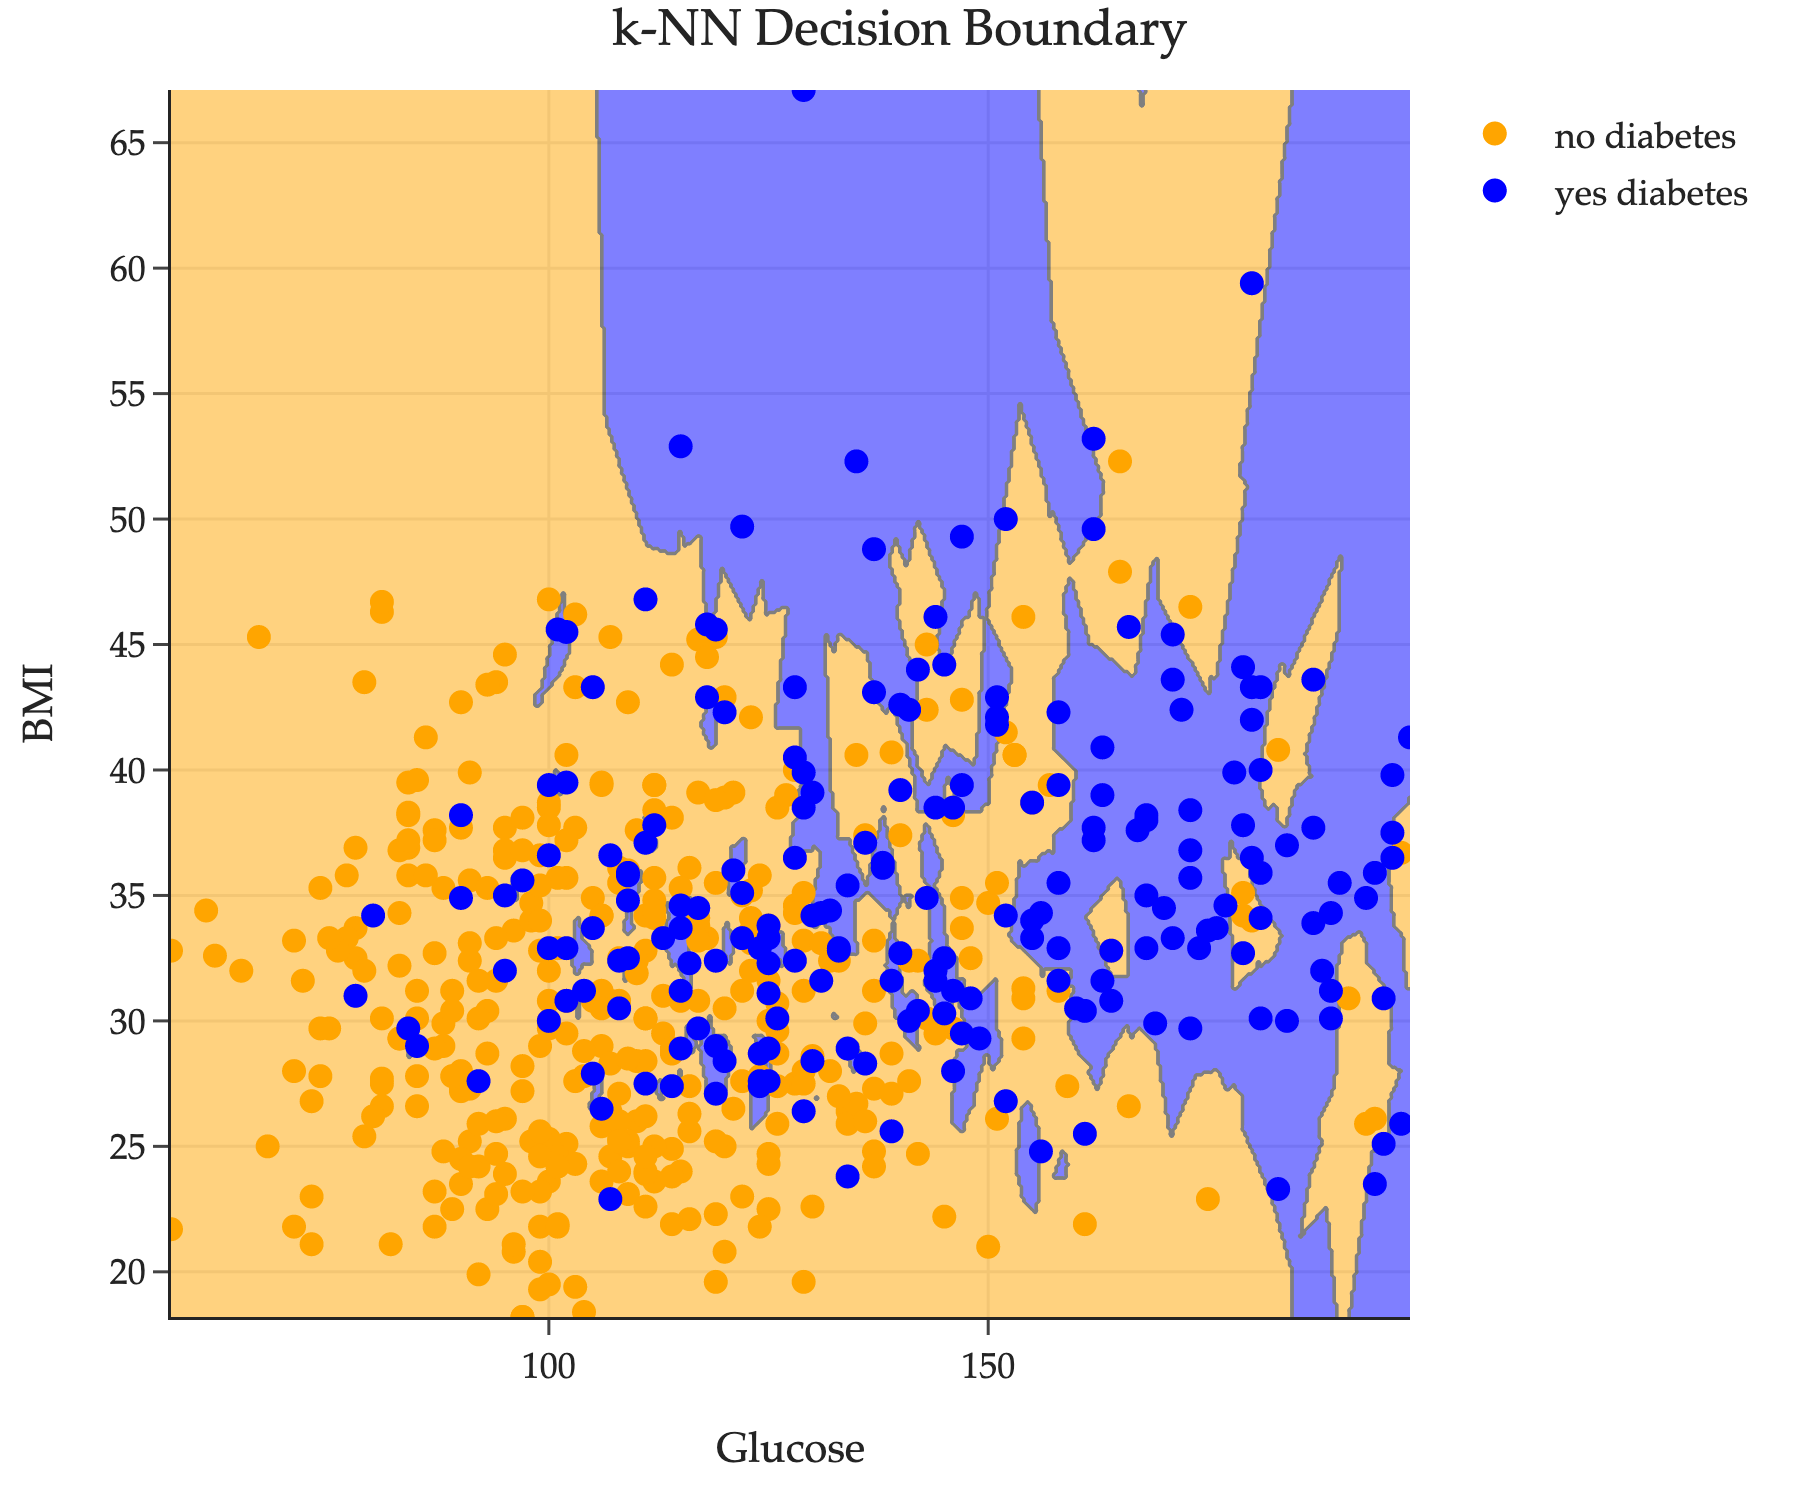

In [11]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=2)
model.fit(X_train, y_train)

fig = util.show_decision_boundary(model, X_train, y_train, title='', grid_n=500)
fig.update_layout(
    title='k-NN Decision Boundary',
    font=dict(family='Palatino'),
    width=600
)
fig.show(renderer='png', scale=3)

Another common family of classifiers is **linear classifiers**, where the decision boundary is a **hyperplane**. One such linear classifier is the **logistic regression** classifier. On this dataset, its decision boundary is plotted below.

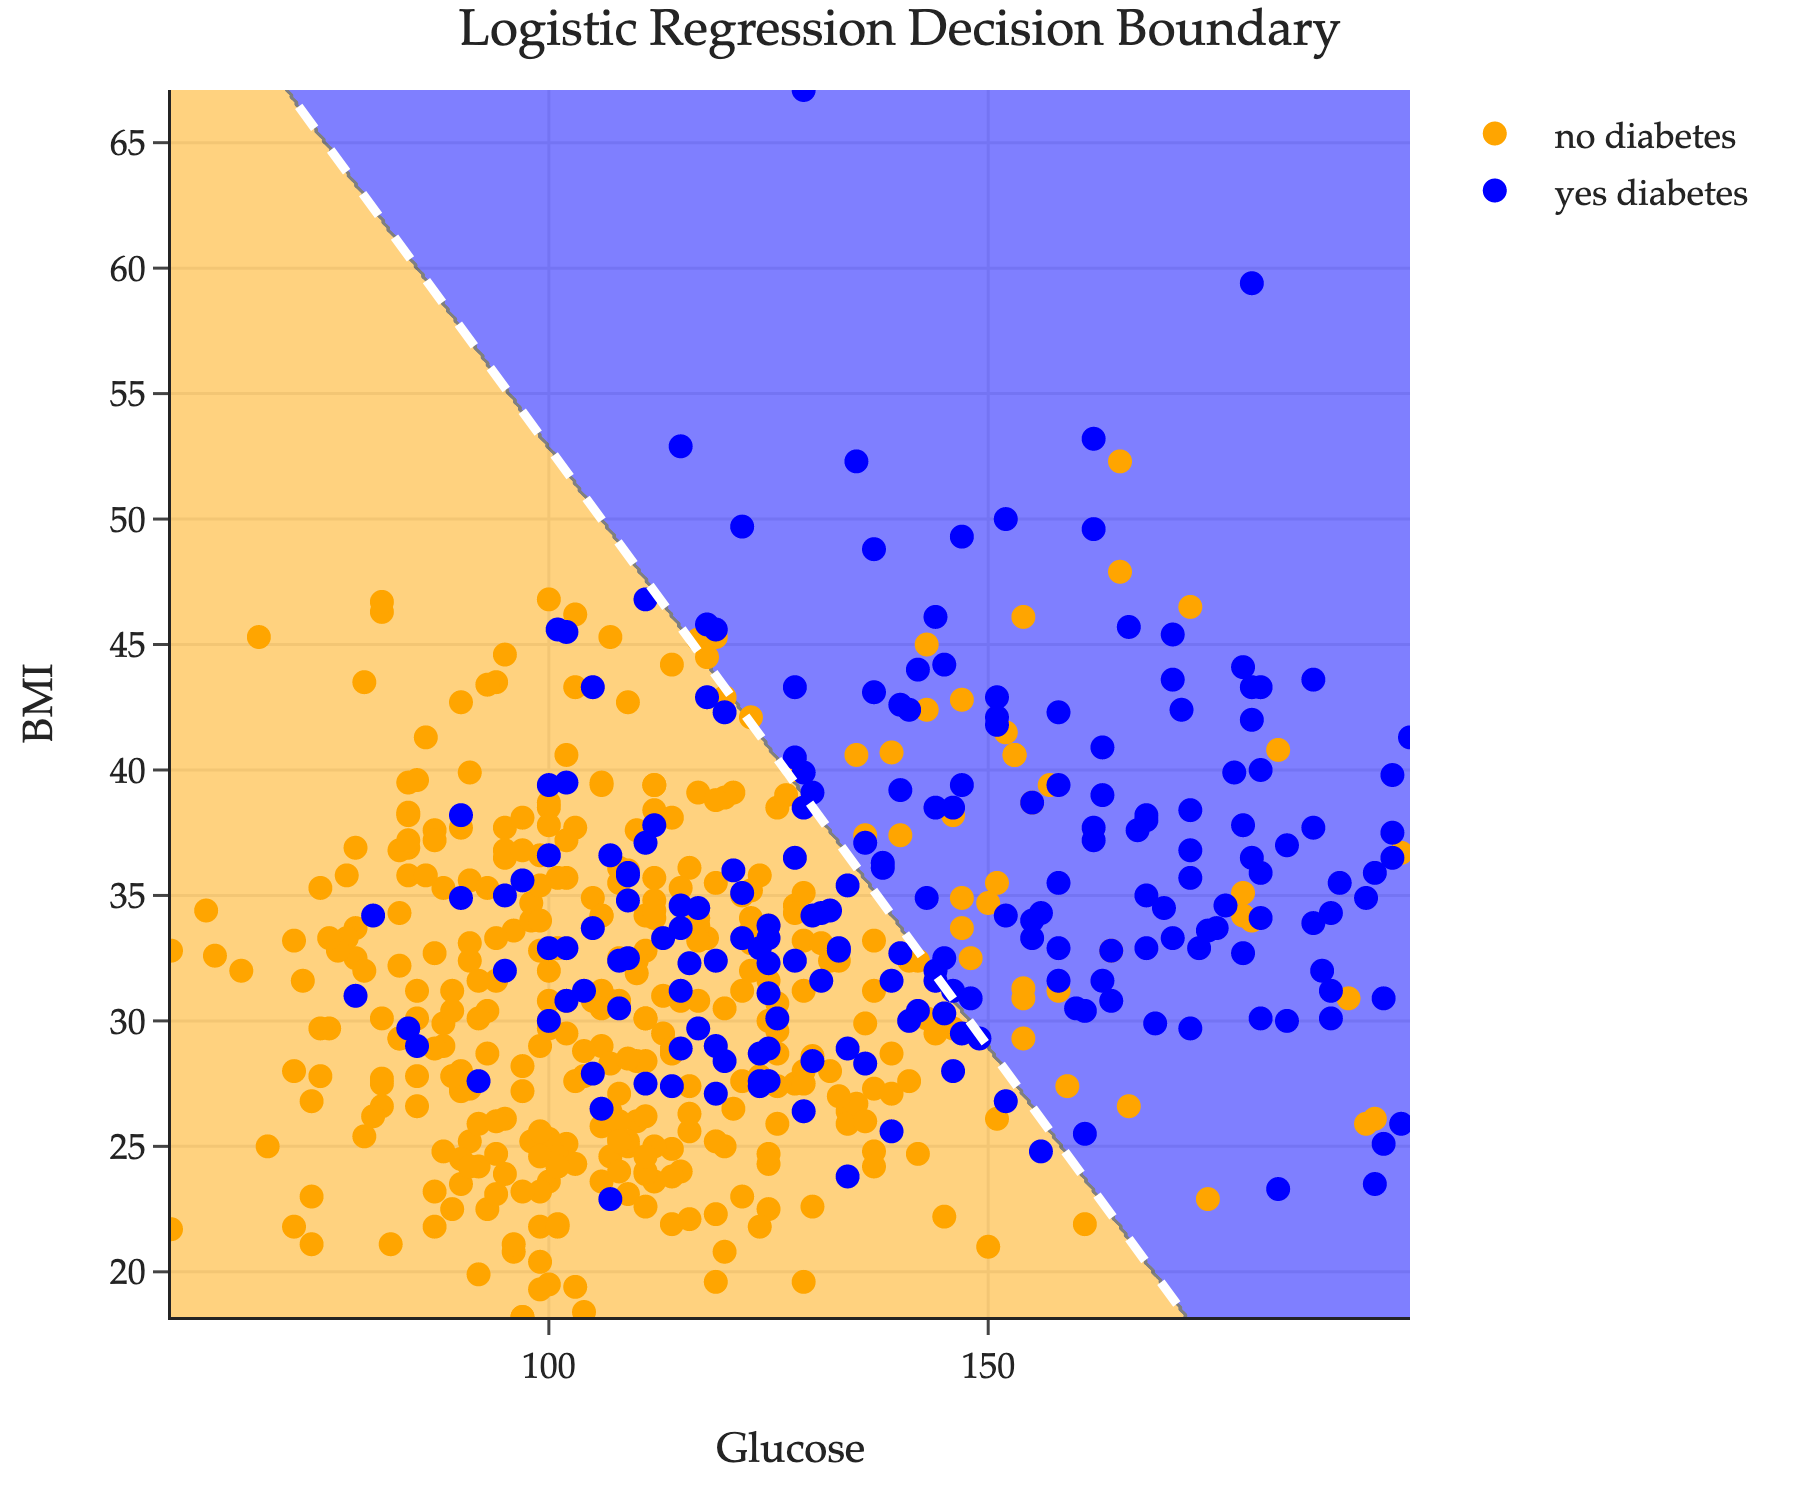

In [21]:
import warnings
warnings.filterwarnings('ignore')
model = LogisticRegression()
model.fit(X_train, y_train)

fig = util.show_decision_boundary(model, X_train, y_train, title='', grid_n=500)
fig.update_layout(
    title='Logistic Regression Decision Boundary',
    font=dict(family='Palatino'),
    width=600
)

# Draw a dotted white line on the decision boundary
import numpy as np

# Get the coefficients for the decision boundary: w1 * x1 + w2 * x2 + b = 0
coef = model.coef_[0]
intercept = model.intercept_[0]

import plotly.graph_objects as go
# x1 will range from min to max Glucose value in the training set
x1_vals = np.linspace(X_train['Glucose'].min(), X_train['Glucose'].max(), 200)
# x2 = (-b - w1*x1)/w2
x2_vals = (-intercept - coef[0] * x1_vals) / coef[1]

fig.add_trace(
    go.Scatter(
        x=x1_vals,
        y=x2_vals,
        mode='lines',
        line=dict(color='white', dash='dash', width=3),
        name='',
    ),
)

fig.show(renderer='png', scale=3)

Here the decision boundary looks like a **line** because the data is only 2-dimensional, but in general (with more than two features) a linear classifier's decision boundary is a hyperplane in $\mathbb{R}^n$. The $\vec w$ in the decision boundary equation $\vec w \cdot \vec x + b = 0$ comes from minimizing empirical risk, for some model and loss function!

We can even peek at the decision boundary:

In [14]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [15]:
model.coef_

array([[0.04, 0.08]])

In [16]:
model.intercept_

array([-7.85])

This is telling us that the decision boundary is of the form $$0.04 \cdot \text{Glucose}_i + 0.08 \cdot \text{BMI}_i - 7.85 = 0$$

or

$$\underbrace{\begin{bmatrix} 0.04 \\ 0.08 \end{bmatrix}}_{\vec w^*} \cdot \underbrace{\begin{bmatrix} \text{Glucose}_i \\ \text{BMI}_i \end{bmatrix}}_{\vec x_i} - 7.85 = 0$$

If this classifier used more features, then the decision boundary would involve more terms. Either way, it would be a hyperplane in $\mathbb{R}^d$, where $d$ is the number of features used. Here, $d = 2$, so the decision boundary is a $(d-1)$-dimensional hyperplane in $\mathbb{R}^2$, i.e. a line in $\mathbb{R}^2$.

The specifics of logistic regression and how it works are beyond the scope of our course, and certainly not relevant to this section of the notes. I've provided this example here just to give you context for where hyperplanes come up in machine learning.